# BehaviourSpace Sensitivity Analysis

Notebook для аналізу результатів NetLogo BehaviourSpace.

Мета: зрозуміти, які параметри моделі найбільше впливають на KPI: profit, revenue, visits, loyalty cost, satisfaction тощо.

## Імпорт бібліотек

In [42]:
import pandas as pd
import re
import ast
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

pd.set_option("display.max_columns", 100)

## Завантаження CSV з BehaviourSpace

Вкажи шлях до файлу, який експортував NetLogo BehaviourSpace.

In [43]:
def keep_final_step_columns(df):
    base_cols = []
    metric_groups = {}

    for col in df.columns:
        match = re.match(r"^(.*)\.(\d+)$", col)

        if match:
            base_name = match.group(1)
            step = int(match.group(2))
            metric_groups.setdefault(base_name, []).append((step, col))
        else:
            base_cols.append(col)

    final_metric_cols = {}

    for base_name, items in metric_groups.items():
        last_step, last_col = max(items, key=lambda x: x[0])
        final_metric_cols[last_col] = base_name

    final_df = df[base_cols + list(final_metric_cols.keys())].copy()
    final_df = final_df.rename(columns=final_metric_cols)

    return final_df


In [44]:
# file_path = "./loyalty-cafes-simple-experiment-spreadsheet.csv"
# file_path = "./loyalty-cafes-simple-experiment-stats.csv"
file_path = "./loyalty-cafes-simple-experiment-table.csv"

df_source = pd.read_csv(file_path, skiprows=6)

df = keep_final_step_columns(df_source)

df.columns.tolist()

df.head()


,[run number],satisfaction-purchase-factor,number-of-customers,recommendation-probability,recommendation-boost,base-purchase-probability,mass-market-capacity,premium-capacity,loyalty-effect-multiplier,network-type,[step],sum [profit] of cafes,sum [revenue] of cafes,sum [loyalty-cost] of cafes,sum [visits] of cafes,sum [lost-visits] of customers,mean [satisfaction] of customers,[profit] of one-of cafes with [cafe-id = 0],[profit] of one-of cafes with [cafe-id = 1],[profit] of one-of cafes with [cafe-id = 2],[profit] of one-of cafes with [cafe-id = 3],[profit] of one-of cafes with [cafe-id = 4],[visits] of one-of cafes with [cafe-id = 0],[visits] of one-of cafes with [cafe-id = 1],[visits] of one-of cafes with [cafe-id = 2],[visits] of one-of cafes with [cafe-id = 3],[visits] of one-of cafes with [cafe-id = 4]
0,4,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.754011,0,0.0,0.0,0,0.0,0,0,0,0,0
1,8,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.750246,0,0.0,0.0,0,0.0,0,0,0,0,0
2,2,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.752941,0,0.0,0.0,0,0.0,0,0,0,0,0
3,6,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.751235,0,0.0,0.0,0,0.0,0,0,0,0,0
4,5,0.2,2000,0.1,0,0.2,500,100,0.5,no network,0,0.0,0,0.0,0,0,0.749274,0,0.0,0.0,0,0.0,0,0,0,0,0


Перевіряємо дані.

In [46]:
df.describe(include="all")

,[run number],satisfaction-purchase-factor,number-of-customers,recommendation-probability,recommendation-boost,base-purchase-probability,mass-market-capacity,premium-capacity,loyalty-effect-multiplier,network-type,[step],sum [profit] of cafes,sum [revenue] of cafes,sum [loyalty-cost] of cafes,sum [visits] of cafes,sum [lost-visits] of customers,mean [satisfaction] of customers,[profit] of one-of cafes with [cafe-id = 0],[profit] of one-of cafes with [cafe-id = 1],[profit] of one-of cafes with [cafe-id = 2],[profit] of one-of cafes with [cafe-id = 3],[profit] of one-of cafes with [cafe-id = 4],[visits] of one-of cafes with [cafe-id = 0],[visits] of one-of cafes with [cafe-id = 1],[visits] of one-of cafes with [cafe-id = 2],[visits] of one-of cafes with [cafe-id = 3],[visits] of one-of cafes with [cafe-id = 4]
count,592920.000000,5.929200e+05,592920.0,592920.000000,592920.000000,5.929200e+05,592920.0,592920.000000,592920.000000,592920,592920.000000,5.929200e+05,5.929200e+05,5.929200e+05,592920.000000,592920.000000,592920.000000,5.929200e+05,5.929200e+05,5.929200e+05,592920.000000,5.929200e+05,592920.000000,592920.000000,592920.000000,592920.000000,592920.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no network,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,197640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,810.500000,2.000000e-01,2000.0,0.283333,5.000000,2.000000e-01,500.0,125.000000,1.333333,NaN,182.500000,2.551631e+06,1.090604e+07,4.846207e+05,318394.905599,19512.515424,0.863819,6.325405e+05,5.017307e+05,5.018718e+05,331747.728294,5.837405e+05,90362.922264,91223.758203,91249.412368,22768.356087,22790.456677
std,467.654023,5.551120e-17,0.0,0.164992,4.082486,5.551120e-17,0.0,25.000021,0.623610,NaN,105.654794,1.484808e+06,6.340486e+06,2.883551e+05,184626.798970,19938.524861,0.054777,3.666828e+05,2.904975e+05,2.905496e+05,201896.750970,3.620031e+05,52383.262167,52817.728835,52827.197651,14178.131022,14210.655990
min,1.000000,2.000000e-01,2000.0,0.100000,0.000000,2.000000e-01,500.0,100.000000,0.500000,NaN,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.739565,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,405.750000,2.000000e-01,2000.0,0.100000,0.000000,2.000000e-01,500.0,100.000000,0.500000,NaN,91.000000,1.271485e+06,5.414320e+06,2.363884e+05,158128.500000,2939.000000,0.811883,3.150000e+05,2.502500e+05,2.502500e+05,163260.000000,2.806342e+05,45000.000000,45500.000000,45500.000000,10900.000000,10900.000000
50%,810.500000,2.000000e-01,2000.0,0.250000,5.000000,2.000000e-01,500.0,125.000000,1.500000,NaN,182.500000,2.539305e+06,1.087636e+07,4.807371e+05,317900.000000,13288.000000,0.875937,6.320510e+05,5.005000e+05,5.017348e+05,318825.000000,5.605036e+05,90293.000000,91000.000000,91224.500000,21900.000000,21900.000000
75%,1215.250000,2.000000e-01,2000.0,0.500000,10.000000,2.000000e-01,500.0,150.000000,2.000000,NaN,274.000000,3.807196e+06,1.633914e+07,7.251005e+05,477700.000000,29012.000000,0.913653,9.486610e+05,7.535000e+05,7.535000e+05,474396.250000,8.403730e+05,135523.000000,137000.000000,137000.000000,32850.000000,32850.000000


## Базове очищення назв колонок

BehaviourSpace іноді додає пробіли або службові колонки. Тут ми трохи нормалізуємо назви.

In [48]:
df.columns = [str(c).strip() for c in df.columns]

# Часто у BehaviourSpace є службові колонки, їх можна залишити або прибрати нижче.
print(df.columns.tolist())

['[run number]', 'satisfaction-purchase-factor', 'number-of-customers', 'recommendation-probability', 'recommendation-boost', 'base-purchase-probability', 'mass-market-capacity', 'premium-capacity', 'loyalty-effect-multiplier', 'network-type', '[step]', 'sum [profit] of cafes', 'sum [revenue] of cafes', 'sum [loyalty-cost] of cafes', 'sum [visits] of cafes', 'sum [lost-visits] of customers', 'mean [satisfaction] of customers', '[profit] of one-of cafes with [cafe-id = 0]', '[profit] of one-of cafes with [cafe-id = 1]', '[profit] of one-of cafes with [cafe-id = 2]', '[profit] of one-of cafes with [cafe-id = 3]', '[profit] of one-of cafes with [cafe-id = 4]', '[visits] of one-of cafes with [cafe-id = 0]', '[visits] of one-of cafes with [cafe-id = 1]', '[visits] of one-of cafes with [cafe-id = 2]', '[visits] of one-of cafes with [cafe-id = 3]', '[visits] of one-of cafes with [cafe-id = 4]']


## Налаштування параметрів і KPI

Перевір назви колонок у попередньому виводі й за потреби відредагуй списки.

In [49]:
parameter_columns = [
    "network-type",
    "number-of-customers",
    "loyalty-effect-multiplier",
    "recommendation-probability",
    "recommendation-boost",
    "mass-market-capacity",
    "premium-capacity",
]

kpi_columns = [
    "sum [profit] of cafes",
    "sum [revenue] of cafes",
    "sum [loyalty-cost] of cafes",
    "sum [visits] of cafes",
    "sum [lost-visits] of customers",
    "mean [satisfaction] of customers",
]

existing_parameters = [c for c in parameter_columns if c in df.columns]
existing_kpis = [c for c in kpi_columns if c in df.columns]

missing_parameters = [c for c in parameter_columns if c not in df.columns]
missing_kpis = [c for c in kpi_columns if c not in df.columns]

print("Existing parameters:", existing_parameters)
print("Missing parameters:", missing_parameters)
print("Existing KPI:", existing_kpis)
print("Missing KPI:", missing_kpis)

Existing parameters: ['network-type', 'number-of-customers', 'loyalty-effect-multiplier', 'recommendation-probability', 'recommendation-boost', 'mass-market-capacity', 'premium-capacity']
Missing parameters: []
Existing KPI: ['sum [profit] of cafes', 'sum [revenue] of cafes', 'sum [loyalty-cost] of cafes', 'sum [visits] of cafes', 'sum [lost-visits] of customers', 'mean [satisfaction] of customers']
Missing KPI: []


## Агрегація повторів експерименту

Якщо BehaviourSpace має кілька повторів для однакових параметрів, краще усереднити KPI.

In [50]:
if existing_parameters and existing_kpis:
    grouped = (
        df[existing_parameters + existing_kpis]
        .dropna()
        .groupby(existing_parameters, as_index=False)
        .agg({kpi: "mean" for kpi in existing_kpis})
    )
else:
    grouped = df.copy()

print("Rows before aggregation:", len(df))
print("Rows after aggregation:", len(grouped))
grouped.head()

Rows before aggregation: 592920
Rows after aggregation: 162


,network-type,number-of-customers,loyalty-effect-multiplier,recommendation-probability,recommendation-boost,mass-market-capacity,premium-capacity,sum [profit] of cafes,sum [revenue] of cafes,sum [loyalty-cost] of cafes,sum [visits] of cafes,sum [lost-visits] of customers,mean [satisfaction] of customers
0,no network,2000,0.5,0.1,0,500,100,2.376611e+06,1.039266e+07,442323.847978,310248.925410,20340.198087,0.810049
1,no network,2000,0.5,0.1,0,500,150,2.702644e+06,1.131531e+07,525858.419221,323149.185519,1326.893443,0.781349
2,no network,2000,0.5,0.1,5,500,100,2.376097e+06,1.039223e+07,442450.712295,310247.266120,19611.208197,0.811381
3,no network,2000,0.5,0.1,5,500,150,2.700189e+06,1.131797e+07,526905.769932,323337.120765,1586.663934,0.784386
4,no network,2000,0.5,0.1,10,500,100,2.375478e+06,1.039174e+07,442665.835465,310243.313661,18727.086885,0.809636


## Функція аналізу важливості параметрів

Використовуємо Random Forest + permutation importance. Це добре підходить для нелінійної агентної моделі.

In [51]:
def analyze_parameter_importance(data, parameter_columns, target_column, test_size=0.25, random_state=42):
    data = data[parameter_columns + [target_column]].dropna().copy()

    X = data[parameter_columns]
    y = data[target_column]

    categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features),
        ]
    )

    model = RandomForestRegressor(
        n_estimators=500,
        random_state=random_state,
        min_samples_leaf=3,
        n_jobs=-1,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    metrics = {
        "target": target_column,
        "r2": r2_score(y_test, predictions),
        "mae": mean_absolute_error(y_test, predictions),
    }

    importance = permutation_importance(
        pipeline,
        X_test,
        y_test,
        n_repeats=20,
        random_state=random_state,
        n_jobs=-1,
    )

    importance_df = pd.DataFrame({
        "parameter": X.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return pipeline, metrics, importance_df

## Аналіз одного KPI

Зміни `target_column`, щоб аналізувати інший результат.

In [52]:
target_column = "sum [profit] of cafes"

if target_column not in grouped.columns:
    raise ValueError(f"Column not found: {target_column}")

pipeline, metrics, importance_df = analyze_parameter_importance(
    grouped,
    existing_parameters,
    target_column,
)

print(metrics)
importance_df

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/joblib_memmapping_folder_66425_d76d9d1b22434e2881e37f328e528b6a_24319b56e1d549b8bff7b5275890bd3a for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-66425-h7hjb3ff for automatic cleanup: unknown resource type semlock
Traceback (most recent call la

{'target': 'sum [profit] of cafes', 'r2': 0.9996931575199635, 'mae': 1773.8174639224505}


Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-31708-_js0zyr1 for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /loky-31708-pulbyzv_ for automatic cleanup: unknown resource type semlock
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiproces

,parameter,importance_mean,importance_std
6,premium-capacity,1.991238e+00,3.942616e-01
2,loyalty-effect-multiplier,7.198937e-03,2.340250e-03
3,recommendation-probability,1.874208e-05,2.511977e-05
1,number-of-customers,2.775558e-17,4.807407e-17
5,mass-market-capacity,1.665335e-17,3.964289e-17
0,network-type,-1.142140e-05,1.683883e-05
4,recommendation-boost,-3.286325e-05,2.704880e-05


## Графік важливості параметрів

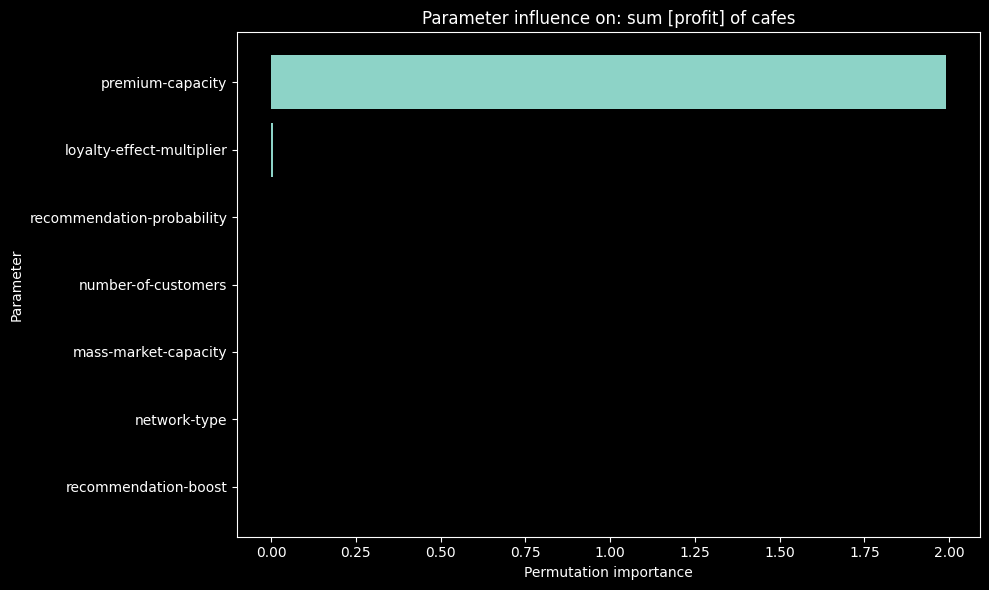

In [53]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["parameter"], importance_df["importance_mean"])
plt.xlabel("Permutation importance")
plt.ylabel("Parameter")
plt.title(f"Parameter influence on: {target_column}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Аналіз усіх KPI одразу

In [54]:
all_results = []
model_quality = []

for kpi in existing_kpis:
    try:
        _, metrics, imp = analyze_parameter_importance(grouped, existing_parameters, kpi)
        imp = imp.copy()
        imp["target"] = kpi
        all_results.append(imp)
        model_quality.append(metrics)
    except Exception as e:
        print(f"Failed for {kpi}: {e}")

importance_all = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
quality_df = pd.DataFrame(model_quality)

quality_df

Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/joblib_memmapping_folder_66425_e79e9e324a094cb69beed64a6cd20064_fc32865ef68a4d3fafabcd19ccc8756b for automatic cleanup: unknown resource type folder
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.14_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/resource_tracker.py", line 450, in main
    raise ValueError(
        f'Cannot register {name} for automatic cleanup: '
        f'unknown resource type {rtype}')
ValueError: Cannot register /var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/joblib_memmapping_folder_66425_d76d9d1b22434e2881e37f32

,target,r2,mae
0,sum [profit] of cafes,0.999693,1773.817464
1,sum [revenue] of cafes,0.999560,4357.634347
2,sum [loyalty-cost] of cafes,0.999885,367.899621
3,sum [visits] of cafes,0.998202,130.532124
4,sum [lost-visits] of customers,0.998366,396.075044
5,mean [satisfaction] of customers,0.998163,0.001483


## 10. Таблиця важливості параметрів по всіх KPI

In [55]:
importance_pivot = importance_all.pivot_table(
    index="parameter",
    columns="target",
    values="importance_mean",
    aggfunc="mean"
)

importance_pivot

target,mean [satisfaction] of customers,sum [lost-visits] of customers,sum [loyalty-cost] of cafes,sum [profit] of cafes,sum [revenue] of cafes,sum [visits] of cafes
parameter,,,,,,
loyalty-effect-multiplier,1.737112e+00,0.481979,4.192361e-04,7.198937e-03,1.381057e-02,5.089168e-02
mass-market-capacity,9.436896e-17,0.000000,0.000000e+00,-9.992007e-17,5.551115e-18,4.996004e-17
network-type,1.049242e-03,0.000142,6.840023e-05,-1.142140e-05,-6.239837e-06,-2.251607e-06
number-of-customers,9.992007e-17,0.000000,0.000000e+00,-1.054712e-16,0.000000e+00,5.551115e-18
premium-capacity,2.419349e-01,1.595536,1.994604e+00,1.991238e+00,1.985928e+00,1.960889e+00
recommendation-boost,1.430219e-03,0.000025,2.823554e-05,-3.286325e-05,-1.761090e-05,1.258182e-04
recommendation-probability,4.741518e-06,0.000118,-1.489912e-07,1.874208e-05,2.697943e-05,7.996200e-05


## 11. Heatmap важливості параметрів

Темніші/більші значення означають сильніший вплив параметра на KPI.

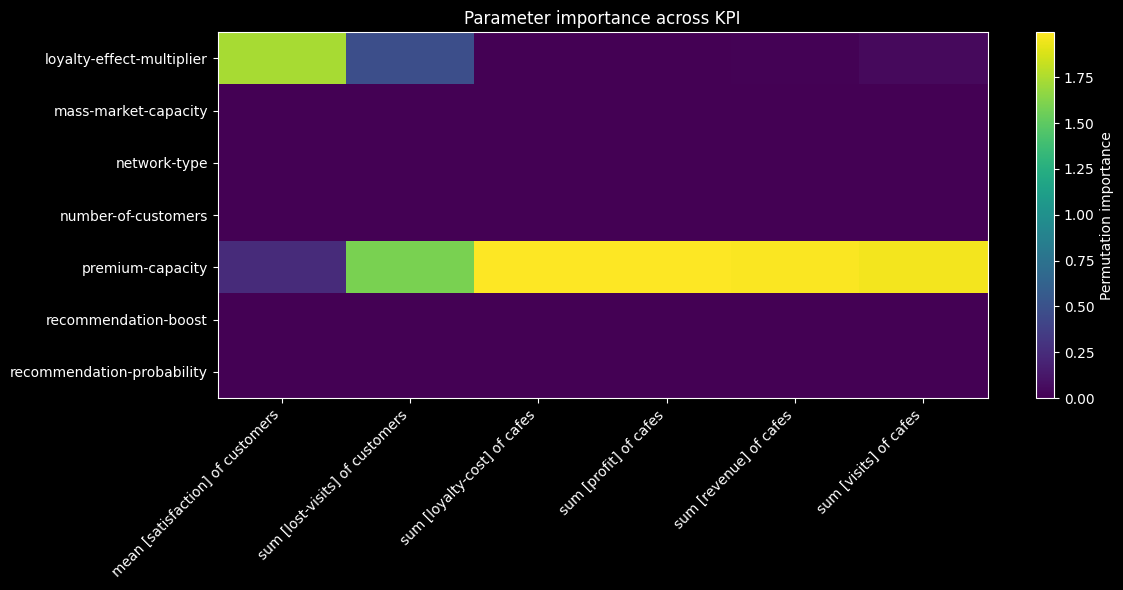

In [56]:
plt.figure(figsize=(12, 6))
plt.imshow(importance_pivot.fillna(0), aspect="auto")
plt.colorbar(label="Permutation importance")
plt.xticks(range(len(importance_pivot.columns)), importance_pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(importance_pivot.index)), importance_pivot.index)
plt.title("Parameter importance across KPI")
plt.tight_layout()
plt.show()

## 12. Grouped summary для одного параметра

Корисно, щоб побачити не лише важливість, а й напрям впливу. Наприклад, як змінюється profit для різних `network-type`.

In [57]:
parameter_to_inspect = "network-type"
target_to_inspect = "sum [profit] of cafes"

summary = grouped.groupby(parameter_to_inspect)[target_to_inspect].agg(["mean", "std", "min", "max", "count"])
summary

,mean,std,min,max,count
network-type,,,,,
no network,2.551675e+06,177689.366784,2.374252e+06,2.740760e+06,54
preferential attachment,2.551729e+06,177622.410494,2.374236e+06,2.740993e+06,54
small world,2.551490e+06,177548.520737,2.373700e+06,2.742395e+06,54


## 13. Boxplot для одного параметра

/var/folders/p_/yh52zt9953v7py3ry5z3kms00000gn/T/ipykernel_66425/251796033.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels)


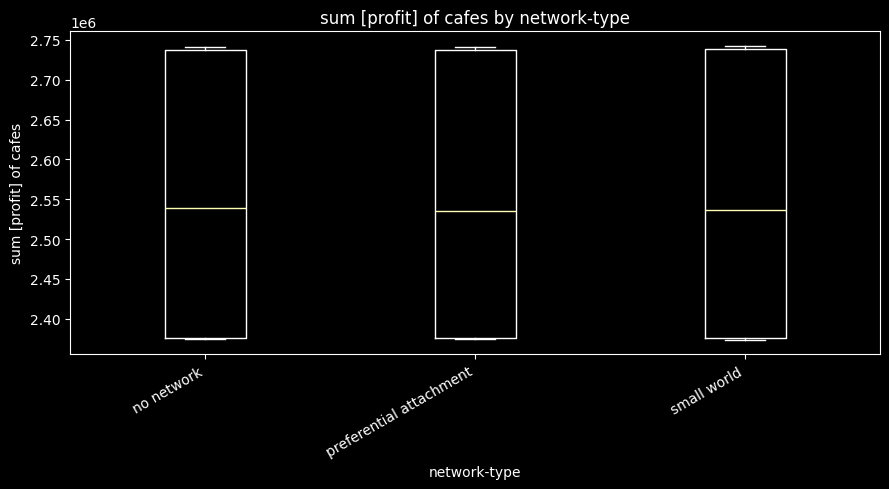

In [58]:
parameter_to_inspect = "network-type"
target_to_inspect = "sum [profit] of cafes"

labels = []
values = []

for name, group in grouped.groupby(parameter_to_inspect):
    labels.append(str(name))
    values.append(group[target_to_inspect].dropna().values)

plt.figure(figsize=(9, 5))
plt.boxplot(values, labels=labels)
plt.ylabel(target_to_inspect)
plt.xlabel(parameter_to_inspect)
plt.title(f"{target_to_inspect} by {parameter_to_inspect}")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 14. Збереження результатів

In [59]:
importance_df.to_csv("parameter_importance_single_kpi.csv", index=False)
importance_all.to_csv("parameter_importance_all_kpi.csv", index=False)
quality_df.to_csv("model_quality.csv", index=False)
importance_pivot.to_csv("parameter_importance_pivot.csv")

print("Saved files:")
print("- parameter_importance_single_kpi.csv")
print("- parameter_importance_all_kpi.csv")
print("- model_quality.csv")
print("- parameter_importance_pivot.csv")

Saved files:
- parameter_importance_single_kpi.csv
- parameter_importance_all_kpi.csv
- model_quality.csv
- parameter_importance_pivot.csv


## Як інтерпретувати

- Якщо параметр має велике `importance_mean`, він сильно впливає на вибраний KPI.
- Якщо `R²` низький, модель Random Forest погано пояснює результат — можливо, треба більше повторів або інші параметри.
- Для статті найкраще показати: heatmap важливості, boxplot для `network-type`, і таблицю важливості для `profit`, `market share`, `lost visits`.